# Modelo Jose Omar Regression

## Data Loading

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

data = pd.read_csv("raw_table.csv")

# Verificar dimensiones
print("Shape:", data.shape)

# Ver primeras filas
data.head()

Shape: (1800066, 68)


,NUEVO_ID,WEEK_ID,UC_TRX,ORAL_TRX,IL23_TRX,BRAND1_TRX,BRAND2_TRX,UC_NRX,ORAL_NRX,IL23_NRX,...,STATE_6,STS_OTHER_STS,STATE_7,STATE_8,"(1940, 1960]","(1960, 1980]","(1980, 2000]","(2000, 2020]","(2020, 2030]",ATSEG
0,17962,2024-08-02,0.1652,0.0000,0.0,0.0,0.0,0.0000,0.0000,0.0,...,0,0,0,0,0,0,0,0,0,NaN
1,3802,2024-11-08,1.5024,0.3780,0.0,0.0,0.0,0.0000,0.0000,0.0,...,0,1,0,0,0,1,0,0,0,SEG_C
2,422,2025-04-25,0.3558,0.1906,0.0,0.0,0.0,0.5337,0.2859,0.0,...,0,0,0,0,1,0,0,0,0,SEG_C
3,19765,2024-02-16,0.0000,0.0000,0.0,0.0,0.0,0.0000,0.0000,0.0,...,0,0,0,0,0,0,1,0,0,NaN
4,9647,2024-01-12,0.1652,0.0000,0.0,0.0,0.0,0.2478,0.0000,0.0,...,0,0,0,1,0,1,0,0,0,SEG_A


## 1. Data Preparation

The dataset is prepared by removing observations without segment labels and selecting only numerical features for modeling.

In [14]:
# Eliminar registros sin segmento
df_model = data.dropna(subset=["ATSEG"]).copy()

# Definir X y y
X = df_model.drop(columns=["ATSEG", "NUEVO_ID", "WEEK_ID"])
y = df_model["ATSEG"]

# Solo variables numéricas
X = X.select_dtypes(include=["int64", "float64"])

# 🔍 MOSTRAR RESULTADOS
print("Shape after removing NaNs:", df_model.shape)
print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts(normalize=True) * 100)

print("\nFirst rows of features:")
display(X.head())

Shape after removing NaNs: (1023314, 68)
Feature matrix shape: (1023314, 65)
Target shape: (1023314,)

Target distribution:
ATSEG
SEG_A    53.836457
SEG_B    28.145222
SEG_C    18.018321
Name: proportion, dtype: float64

First rows of features:


,UC_TRX,ORAL_TRX,IL23_TRX,BRAND1_TRX,BRAND2_TRX,UC_NRX,ORAL_NRX,IL23_NRX,BRAND1_NRX,BRAND2_NRX,...,STATE_5,STATE_6,STS_OTHER_STS,STATE_7,STATE_8,"(1940, 1960]","(1960, 1980]","(1980, 2000]","(2000, 2020]","(2020, 2030]"
1,1.5024,0.3780,0.0,0.0,0.0,0.0000,0.0000,0.0,0.0,0.0,...,0,0,1,0,0,0,1,0,0,0
2,0.3558,0.1906,0.0,0.0,0.0,0.5337,0.2859,0.0,0.0,0.0,...,0,0,0,0,0,1,0,0,0,0
4,0.1652,0.0000,0.0,0.0,0.0,0.2478,0.0000,0.0,0.0,0.0,...,0,0,0,0,1,0,1,0,0,0
5,0.9916,0.5996,0.0,0.0,0.0,1.1934,0.8994,0.0,0.0,0.0,...,0,0,1,0,0,0,1,0,0,0
7,0.1680,0.0000,0.0,0.0,0.0,0.0000,0.0000,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0


## 2. Feature Engineering

New features are created to capture total prescription behavior, engagement intensity, and ratios.

New features created:
       TOTAL_PRESCRIPTIONS  ENGAGEMENT_INDEX  ENGAGEMENT_RATIO
count         1.023314e+06      1.023314e+06      1.023314e+06
mean          4.797199e-01      1.327836e-01      9.589920e-02
std           9.634755e-01      5.233504e-01      3.926115e-01
min           0.000000e+00      0.000000e+00      0.000000e+00
25%           0.000000e+00      0.000000e+00      0.000000e+00
50%           1.888000e-01      0.000000e+00      0.000000e+00
75%           5.620000e-01      0.000000e+00      0.000000e+00
max           3.091340e+01      1.070000e+02      6.901445e+01

Sample of new features:


,TOTAL_PRESCRIPTIONS,ENGAGEMENT_INDEX,ENGAGEMENT_RATIO
1,1.8804,0.0,0.000000
2,0.5464,0.6,0.387998
4,0.1652,0.0,0.000000
5,1.5912,0.0,0.000000
7,0.1680,0.0,0.000000


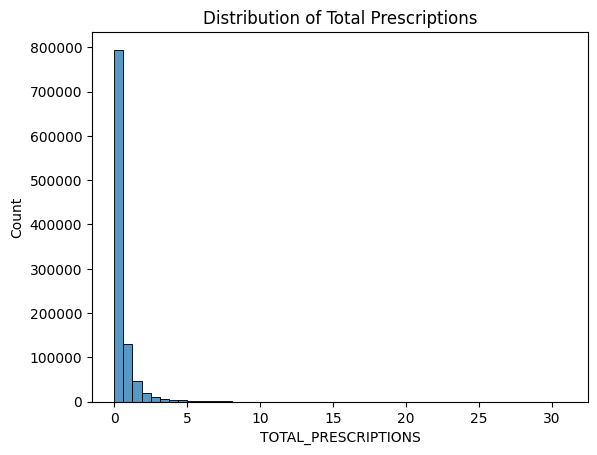

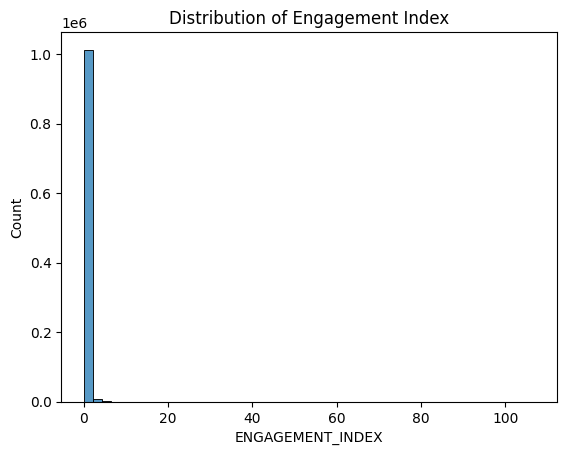

In [15]:
# Total prescriptions per observation
df_model["TOTAL_PRESCRIPTIONS"] = (
    df_model["UC_TRX"] + df_model["ORAL_TRX"] + df_model["IL23_TRX"]
)

# Total engagement per observation
df_model["ENGAGEMENT_INDEX"] = (
    df_model[["RTE", "DETAILS", "SAMPLES"]].sum(axis=1)
)

# Engagement to prescription ratio
df_model["ENGAGEMENT_RATIO"] = (
    df_model["ENGAGEMENT_INDEX"] / (df_model["TOTAL_PRESCRIPTIONS"] + 1)
)

# 🔍 DISPLAY RESULTS
print("New features created:")
print(df_model[["TOTAL_PRESCRIPTIONS", "ENGAGEMENT_INDEX", "ENGAGEMENT_RATIO"]].describe())

print("\nSample of new features:")
display(df_model[["TOTAL_PRESCRIPTIONS", "ENGAGEMENT_INDEX", "ENGAGEMENT_RATIO"]].head())

# Optional: visualize distributions
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df_model["TOTAL_PRESCRIPTIONS"], bins=50)
plt.title("Distribution of Total Prescriptions")
plt.show()

sns.histplot(df_model["ENGAGEMENT_INDEX"], bins=50)
plt.title("Distribution of Engagement Index")
plt.show()

The engineered features show a high level of sparsity, with most observations having zero prescriptions and zero engagement.

## 3. Temporal Aggregation

Since each doctor has 86 weeks of data, we aggregate behavior at the doctor level.

In [16]:
# Aggregate weekly data at doctor level
df_agg = df_model.groupby("NUEVO_ID").agg({
    "TOTAL_PRESCRIPTIONS": ["mean", "max"],
    "ENGAGEMENT_INDEX": ["mean"],
    "ENGAGEMENT_RATIO": ["mean"],
}).reset_index()

# Flatten column names
df_agg.columns = ["_".join(col).strip("_") for col in df_agg.columns]

# Define target segment at doctor level
target = df_model.groupby("NUEVO_ID")["ATSEG"].agg(lambda x: x.mode()[0]).reset_index()

# Merge features and target
df_final = df_agg.merge(target, on="NUEVO_ID")

# 🔍 DISPLAY RESULTS
print("Aggregated dataset shape:", df_final.shape)

print("\nTarget distribution at doctor level:")
print(df_final["ATSEG"].value_counts())

print("\nSample of aggregated data:")
display(df_final.head())

print("\nSummary statistics:")
display(df_final.describe())

Aggregated dataset shape: (11899, 6)

Target distribution at doctor level:
ATSEG
SEG_A    6406
SEG_B    3349
SEG_C    2144
Name: count, dtype: int64

Sample of aggregated data:


,NUEVO_ID,TOTAL_PRESCRIPTIONS_mean,TOTAL_PRESCRIPTIONS_max,ENGAGEMENT_INDEX_mean,ENGAGEMENT_RATIO_mean,ATSEG
0,3,0.192200,0.6610,0.153488,0.129417,SEG_A
1,11,0.080474,1.3842,0.187209,0.177688,SEG_A
2,18,0.502167,1.7452,0.181395,0.128011,SEG_A
3,19,0.083621,1.4920,0.179070,0.166076,SEG_A
4,20,0.089442,0.7024,0.000000,0.000000,SEG_A



Summary statistics:


,NUEVO_ID,TOTAL_PRESCRIPTIONS_mean,TOTAL_PRESCRIPTIONS_max,ENGAGEMENT_INDEX_mean,ENGAGEMENT_RATIO_mean
count,11899.000000,11899.000000,11899.000000,11899.000000,11899.000000
mean,8166.352635,0.479720,1.644792,0.132784,0.095899
std,4992.404759,0.849166,1.659349,0.179914,0.132844
min,3.000000,0.000000,0.000000,0.000000,0.000000
25%,3944.500000,0.102408,0.722600,0.006977,0.006977
50%,7734.000000,0.254000,1.273400,0.076744,0.054805
75%,12175.500000,0.527923,2.015900,0.188372,0.134168
max,20534.000000,20.132077,30.913400,2.339535,2.127748


## 4. Define Features and Target

In [17]:
# Define features and target
X = df_final.drop(columns=["ATSEG", "NUEVO_ID"])
y = df_final["ATSEG"]

# 🔍 DISPLAY RESULTS
print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeature columns:")
print(list(X.columns))

print("\nTarget distribution:")
print(y.value_counts())

print("\nSample of X:")
display(X.head())

print("\nSample of y:")
display(y.head())

Feature matrix shape: (11899, 4)
Target shape: (11899,)

Feature columns:
['TOTAL_PRESCRIPTIONS_mean', 'TOTAL_PRESCRIPTIONS_max', 'ENGAGEMENT_INDEX_mean', 'ENGAGEMENT_RATIO_mean']

Target distribution:
ATSEG
SEG_A    6406
SEG_B    3349
SEG_C    2144
Name: count, dtype: int64

Sample of X:


,TOTAL_PRESCRIPTIONS_mean,TOTAL_PRESCRIPTIONS_max,ENGAGEMENT_INDEX_mean,ENGAGEMENT_RATIO_mean
0,0.192200,0.6610,0.153488,0.129417
1,0.080474,1.3842,0.187209,0.177688
2,0.502167,1.7452,0.181395,0.128011
3,0.083621,1.4920,0.179070,0.166076
4,0.089442,0.7024,0.000000,0.000000



Sample of y:


,ATSEG
0,SEG_A
1,SEG_A
2,SEG_A
3,SEG_A
4,SEG_A


## 5. Train-Test Split

In [18]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 🔍 DISPLAY RESULTS
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

print("\nTarget distribution (Train):")
print(y_train.value_counts(normalize=True) * 100)

print("\nTarget distribution (Test):")
print(y_test.value_counts(normalize=True) * 100)

Training set shape: (9519, 4)
Testing set shape: (2380, 4)

Target distribution (Train):
ATSEG
SEG_A    53.839689
SEG_B    28.143713
SEG_C    18.016598
Name: proportion, dtype: float64

Target distribution (Test):
ATSEG
SEG_A    53.823529
SEG_B    28.151261
SEG_C    18.025210
Name: proportion, dtype: float64


## 6. Feature Scaling

In [19]:
# Apply scaling
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 🔍 DISPLAY RESULTS
print("Scaled training data shape:", X_train_scaled.shape)
print("Scaled testing data shape:", X_test_scaled.shape)

print("\nFirst rows of scaled data:")
display(pd.DataFrame(X_train_scaled, columns=X.columns).head())

print("\nFeature means after scaling (should be ~0):")
print(pd.DataFrame(X_train_scaled, columns=X.columns).mean().head())

print("\nFeature std after scaling (should be ~1):")
print(pd.DataFrame(X_train_scaled, columns=X.columns).std().head())

Scaled training data shape: (9519, 4)
Scaled testing data shape: (2380, 4)

First rows of scaled data:


,TOTAL_PRESCRIPTIONS_mean,TOTAL_PRESCRIPTIONS_max,ENGAGEMENT_INDEX_mean,ENGAGEMENT_RATIO_mean
0,-0.483368,-0.274495,-0.650811,-0.606780
1,-0.562140,-0.988618,-0.689406,-0.658949
2,0.508971,0.454539,0.314072,-0.023864
3,-0.014608,0.554100,1.105276,1.232383
4,-0.025871,0.208161,-0.728001,-0.711117



Feature means after scaling (should be ~0):
TOTAL_PRESCRIPTIONS_mean    5.225128e-18
TOTAL_PRESCRIPTIONS_max    -3.620267e-17
ENGAGEMENT_INDEX_mean       2.202018e-17
ENGAGEMENT_RATIO_mean      -6.643377e-17
dtype: float64

Feature std after scaling (should be ~1):
TOTAL_PRESCRIPTIONS_mean    1.000053
TOTAL_PRESCRIPTIONS_max     1.000053
ENGAGEMENT_INDEX_mean       1.000053
ENGAGEMENT_RATIO_mean       1.000053
dtype: float64


## 7. Baseline Model (Dummy)

A baseline model is used to compare performance.

In [20]:
# Train dummy model
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)

# Predictions
y_dummy_pred = dummy.predict(X_test)

# 🔍 DISPLAY RESULTS
print("Dummy Accuracy:", dummy.score(X_test, y_test))

print("\nClassification Report (Dummy Model):")
print(classification_report(y_test, y_dummy_pred))

print("\nTarget distribution in test set:")
print(y_test.value_counts(normalize=True) * 100)

Dummy Accuracy: 0.538235294117647

Classification Report (Dummy Model):
              precision    recall  f1-score   support

       SEG_A       0.54      1.00      0.70      1281
       SEG_B       0.00      0.00      0.00       670
       SEG_C       0.00      0.00      0.00       429

    accuracy                           0.54      2380
   macro avg       0.18      0.33      0.23      2380
weighted avg       0.29      0.54      0.38      2380


Target distribution in test set:
ATSEG
SEG_A    53.823529
SEG_B    28.151261
SEG_C    18.025210
Name: proportion, dtype: float64


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## 8. Model Training (Logistic Regression)

In [21]:
# Train Logistic Regression model
model = LogisticRegression(max_iter=1000)

model.fit(X_train_scaled, y_train)

# 🔍 DISPLAY RESULTS
print("Model trained successfully")

print("\nClasses:")
print(model.classes_)

print("\nNumber of features used:", X_train.shape[1])

print("\nIntercept (bias term):")
print(model.intercept_)

print("\nSample of coefficients:")
coef_df_preview = pd.DataFrame(model.coef_, columns=X.columns, index=model.classes_)
display(coef_df_preview.iloc[:, :5])

Model trained successfully

Classes:
['SEG_A' 'SEG_B' 'SEG_C']

Number of features used: 4

Intercept (bias term):
[ 0.32028326  0.0743547  -0.39463796]

Sample of coefficients:


,TOTAL_PRESCRIPTIONS_mean,TOTAL_PRESCRIPTIONS_max,ENGAGEMENT_INDEX_mean,ENGAGEMENT_RATIO_mean
SEG_A,-1.365199,-0.458579,-0.343464,0.207510
SEG_B,0.477422,0.359032,0.247909,-0.172378
SEG_C,0.887777,0.099547,0.095555,-0.035131


## 9. Predictions

In [22]:
# Generate predictions
y_pred = model.predict(X_test_scaled)

# 🔍 DISPLAY RESULTS
print("First 10 predictions:")
print(y_pred[:10])

print("\nActual vs Predicted (first 10):")
comparison = pd.DataFrame({
    "Actual": y_test.values[:10],
    "Predicted": y_pred[:10]
})
display(comparison)

print("\nPrediction distribution:")
print(pd.Series(y_pred).value_counts())

First 10 predictions:
['SEG_A' 'SEG_B' 'SEG_A' 'SEG_B' 'SEG_A' 'SEG_A' 'SEG_A' 'SEG_A' 'SEG_B'
 'SEG_A']

Actual vs Predicted (first 10):


,Actual,Predicted
0,SEG_C,SEG_A
1,SEG_B,SEG_B
2,SEG_C,SEG_A
3,SEG_B,SEG_B
4,SEG_A,SEG_A
5,SEG_A,SEG_A
6,SEG_A,SEG_A
7,SEG_C,SEG_A
8,SEG_B,SEG_B
9,SEG_A,SEG_A



Prediction distribution:
SEG_A    1747
SEG_B     604
SEG_C      29
Name: count, dtype: int64


The model heavily favors SEG_A predictions and rarely predicts SEG_C, indicating difficulty in identifying the minority class

## 10. Evaluation Metrics

In [23]:
# Evaluate model performance
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score (Macro):", f1_score(y_test, y_pred, average="macro"))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# 🔍 EXTRA DISPLAY
results_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

print("\nSample of predictions:")
display(results_df.head(10))

Accuracy: 0.6340336134453781
F1 Score (Macro): 0.4524696106588051

Classification Report:
              precision    recall  f1-score   support

       SEG_A       0.68      0.92      0.78      1281
       SEG_B       0.51      0.46      0.48       670
       SEG_C       0.76      0.05      0.10       429

    accuracy                           0.63      2380
   macro avg       0.65      0.48      0.45      2380
weighted avg       0.64      0.63      0.57      2380


Sample of predictions:


,Actual,Predicted
0,SEG_C,SEG_A
1,SEG_B,SEG_B
2,SEG_C,SEG_A
3,SEG_B,SEG_B
4,SEG_A,SEG_A
5,SEG_A,SEG_A
6,SEG_A,SEG_A
7,SEG_C,SEG_A
8,SEG_B,SEG_B
9,SEG_A,SEG_A


The model improves performance compared to the baseline, increasing accuracy from 54% to 63%

The macro F1-score indicates moderate performance, suggesting that the model struggles with minority classes.

The model has very low recall for SEG_C, meaning it rarely identifies this segment, even though predictions are relatively accurate when it does

## 11. Confusion Matrix

Confusion Matrix (raw values):


,SEG_A,SEG_B,SEG_C
SEG_A,1180,101,0
SEG_B,356,307,7
SEG_C,211,196,22


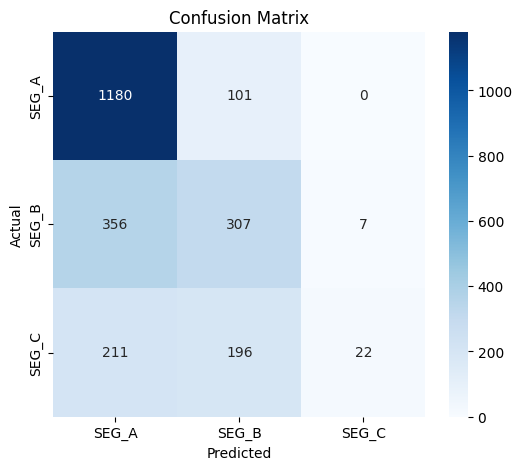


Normalized Confusion Matrix:


,SEG_A,SEG_B,SEG_C
SEG_A,0.921155,0.078845,0.000000
SEG_B,0.531343,0.458209,0.010448
SEG_C,0.491841,0.456876,0.051282


In [24]:
# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Convert to DataFrame for better readability
cm_df = pd.DataFrame(cm, index=model.classes_, columns=model.classes_)

# 🔍 DISPLAY RESULTS
print("Confusion Matrix (raw values):")
display(cm_df)

# Plot heatmap
plt.figure(figsize=(6,5))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# Normalized confusion matrix
cm_norm = cm / cm.sum(axis=1, keepdims=True)
cm_norm_df = pd.DataFrame(cm_norm, index=model.classes_, columns=model.classes_)

print("\nNormalized Confusion Matrix:")
display(cm_norm_df)

## 12. Feature Importance

Top 10 features influencing SEG_C:


,SEG_A,SEG_B,SEG_C
TOTAL_PRESCRIPTIONS_mean,-1.365199,0.477422,0.887777
TOTAL_PRESCRIPTIONS_max,-0.458579,0.359032,0.099547
ENGAGEMENT_INDEX_mean,-0.343464,0.247909,0.095555
ENGAGEMENT_RATIO_mean,0.207510,-0.172378,-0.035131


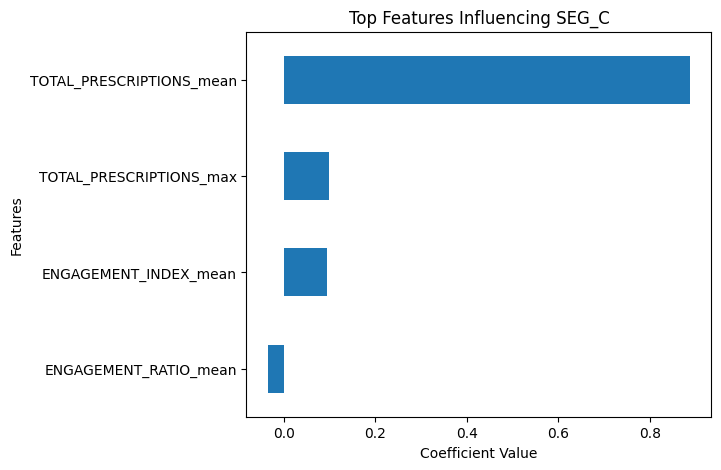

In [25]:
# Create coefficient DataFrame
coef_df = pd.DataFrame(model.coef_, columns=X.columns, index=model.classes_)

# Top features influencing SEG_C
top_features_segC = coef_df.T.sort_values(by="SEG_C", ascending=False).head(10)

# 🔍 DISPLAY RESULTS
print("Top 10 features influencing SEG_C:")
display(top_features_segC)

# Optional: visualize feature importance
plt.figure(figsize=(6,5))
top_features_segC["SEG_C"].sort_values().plot(kind="barh")

plt.title("Top Features Influencing SEG_C")
plt.xlabel("Coefficient Value")
plt.ylabel("Features")

plt.show()

## 14. Model Improvement (Handling Class Imbalance)

In [26]:
# Retrain model with class balancing
model_balanced = LogisticRegression(max_iter=1000, class_weight="balanced")

model_balanced.fit(X_train_scaled, y_train)

# Predictions
y_pred_balanced = model_balanced.predict(X_test_scaled)

# 🔍 DISPLAY RESULTS
print("Balanced Model Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_balanced))
print("F1 Score (Macro):", f1_score(y_test, y_pred_balanced, average="macro"))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_balanced))

print("\nPrediction distribution:")
print(pd.Series(y_pred_balanced).value_counts())

Balanced Model Performance:
Accuracy: 0.6067226890756302
F1 Score (Macro): 0.5142324786897873

Classification Report:
              precision    recall  f1-score   support

       SEG_A       0.74      0.80      0.77      1281
       SEG_B       0.44      0.44      0.44       670
       SEG_C       0.38      0.30      0.33       429

    accuracy                           0.61      2380
   macro avg       0.52      0.51      0.51      2380
weighted avg       0.59      0.61      0.60      2380


Prediction distribution:
SEG_A    1380
SEG_B     663
SEG_C     337
Name: count, dtype: int64


Accuracy slightly decreased after balancing the model, which is expected when improving performance across all classes.

he macro F1-score improved, indicating better performance across all segments.